<div style="background:linear-gradient(90deg,#4F46E5,#7E22CE); color:white; padding:22px 26px; border-radius:8px;">
<div style="font-family:monospace; font-size:0.85em; opacity:0.85;">INF672 · Machine Learning · Cuaderno de práctica</div>
<div style="font-size:1.9em; font-weight:bold; margin-top:6px;">Regresión lineal en dos caminos</div>
<div style="margin-top:6px; opacity:0.9;">A · con scikit-learn &nbsp;&nbsp;|&nbsp;&nbsp; B · con descenso de gradiente desde cero</div>
</div>

## Introducción

La **regresión lineal simple** busca la recta que mejor describe la relación entre una variable de entrada $x$ y una salida $y$:

$$\hat{y} = w\,x + b$$

donde $w$ es la **pendiente** y $b$ el **intercepto**. "Mejor" significa que minimiza el **error cuadrático medio** entre lo predicho y lo real.

En este cuaderno resolvemos el **mismo problema** de dos formas:

- **Parte A — scikit-learn:** usamos `LinearRegression`, que encuentra la solución exacta en una sola llamada. Es lo que se usa en la práctica.
- **Parte B — desde cero:** programamos el **descenso de gradiente** con NumPy para entender qué ocurre por dentro. Es la idea sobre la que se construye casi todo el Machine Learning moderno.

Al final comprobaremos que ambos caminos llegan a los mismos parámetros.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Paleta del curso
INDIGO, PURPURA, CORAL, TINTA = '#4F46E5', '#7E22CE', '#F43F5E', '#111827'
plt.rcParams.update({'figure.figsize': (7, 4.2), 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

## El conjunto de datos

Simulamos las **horas de estudio** (0 a 10) de 60 estudiantes y la **nota** obtenida en un examen (0 a 100). Construimos los datos a partir de una relación "verdadera" conocida más un ruido aleatorio:

$$\text{nota} = 30 + 5 \cdot \text{horas} + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\ 5^2)$$

Así sabemos de antemano la respuesta correcta ($w = 5$, $b = 30$) y podemos juzgar qué tan bien la recupera cada método.

In [2]:
rng = np.random.default_rng(42)          # semilla: resultados reproducibles
m = 60                                    # número de muestras

horas = rng.uniform(0, 10, m)
nota  = 30 + 5 * horas + rng.normal(0, 5, m)

print('Primeras 5 muestras:')
for h, n in zip(horas[:5], nota[:5]):
    print(f'  horas = {h:5.2f}   nota = {n:6.2f}')

Primeras 5 muestras:
  horas =  7.74   nota =  64.37
  horas =  4.39   nota =  56.79
  horas =  8.59   nota =  64.52
  horas =  6.97   nota =  63.19
  horas =  0.94   nota =  35.52


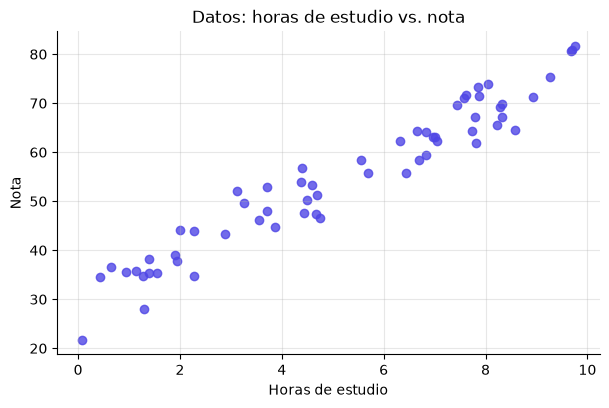

In [3]:
plt.scatter(horas, nota, color=INDIGO, alpha=0.8)
plt.xlabel('Horas de estudio'); plt.ylabel('Nota')
plt.title('Datos: horas de estudio vs. nota')
plt.show()

Se aprecia una tendencia creciente con dispersión: más horas de estudio tienden a dar mejores notas, pero no de forma exacta. Una recta es un modelo razonable.

---
# Parte A — Regresión lineal con scikit-learn

scikit-learn organiza todos sus modelos con la misma interfaz de tres pasos:

1. **Crear** el modelo → `modelo = LinearRegression()`
2. **Entrenar** con los datos → `modelo.fit(X, y)`
3. **Predecir** valores nuevos → `modelo.predict(X_nuevo)`

## A.1 Preparar los datos

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = horas.reshape(-1, 1)   # scikit-learn exige una matriz 2D: (muestras, características)
y = nota                   # el objetivo es un vector 1D

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print('Entrenamiento:', X_train.shape, '  Prueba:', X_test.shape)

Entrenamiento: (48, 1)   Prueba: (12, 1)


<div style="border-left:4px solid #6B7280; background:#F9FAFB; padding:10px 14px; margin:8px 0; border-radius:4px; color:#111827;"><span style="font-family:monospace; font-size:0.8em; color:#6B7280; font-weight:bold;">NOTA</span> <b>¿Por qué reshape(-1, 1) y por qué dividir los datos?</b><br><code>reshape(-1, 1)</code> convierte el vector de 60 valores en una matriz de 60 filas y 1 columna; el <code>-1</code> le pide a NumPy que calcule ese número solo. Separamos un 20 % de los datos como <b>conjunto de prueba</b>: el modelo no lo ve durante el entrenamiento, así que su error ahí mide qué tan bien <i>generaliza</i> a datos nuevos.</div>

## A.2 Entrenar el modelo

In [5]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

w_sk = modelo.coef_[0]      # coef_ es un arreglo: un peso por característica
b_sk = modelo.intercept_    # intercept_ es un número

print(f'Pendiente  w = {w_sk:.4f}   (valor real: 5)')
print(f'Intercepto b = {b_sk:.4f}   (valor real: 30)')
print(f'\nModelo aprendido:  nota = {b_sk:.2f} + {w_sk:.2f} · horas')

Pendiente  w = 5.0675   (valor real: 5)
Intercepto b = 28.5394   (valor real: 30)

Modelo aprendido:  nota = 28.54 + 5.07 · horas


Los parámetros no coinciden exactamente con 5 y 30 porque el modelo solo ve 48 muestras con ruido; aun así, se acercan bastante.

**Interpretación:** cada hora adicional de estudio se asocia con unos $w$ puntos más en la nota; un estudiante que no estudia nada obtendría, según el modelo, unos $b$ puntos.

## A.3 Predecir y evaluar

In [6]:
y_pred = modelo.predict(X_test)

print(f'MAE  (error absoluto medio)       = {mean_absolute_error(y_test, y_pred):.3f} puntos')
print(f'MSE  (error cuadrático medio)     = {mean_squared_error(y_test, y_pred):.3f}')
print(f'RMSE (raíz del MSE)               = {np.sqrt(mean_squared_error(y_test, y_pred)):.3f} puntos')
print(f'R²   (coef. de determinación)     = {r2_score(y_test, y_pred):.3f}')

MAE  (error absoluto medio)       = 2.781 puntos
MSE  (error cuadrático medio)     = 12.188
RMSE (raíz del MSE)               = 3.491 puntos
R²   (coef. de determinación)     = 0.946


<div style="border-left:4px solid #7E22CE; background:#F5F3FF; padding:10px 14px; margin:8px 0; border-radius:4px; color:#111827;"><span style="font-family:monospace; font-size:0.8em; color:#7E22CE; font-weight:bold;">DEFINICIÓN</span> <b>Métricas de regresión</b><br><b>MAE</b>: en promedio, cuántos puntos se equivoca la predicción. <b>RMSE</b>: similar, pero penaliza más los errores grandes; está en las mismas unidades que la nota. <b>R²</b>: proporción de la variabilidad de la nota que explica el modelo (1 = perfecto, 0 = no mejor que predecir siempre la media). El RMSE debe quedar del orden del ruido que pusimos en los datos (σ = 5), que ningún modelo puede eliminar; aquí sale algo menor por azar, porque el conjunto de prueba tiene solo 12 muestras.</div>

In [7]:
# Predicción para estudiantes nuevos
nuevos = np.array([[2], [5], [8]])
for h, p in zip(nuevos.ravel(), modelo.predict(nuevos)):
    print(f'Con {h} horas de estudio se predice una nota de {p:.1f}')

Con 2 horas de estudio se predice una nota de 38.7
Con 5 horas de estudio se predice una nota de 53.9
Con 8 horas de estudio se predice una nota de 69.1


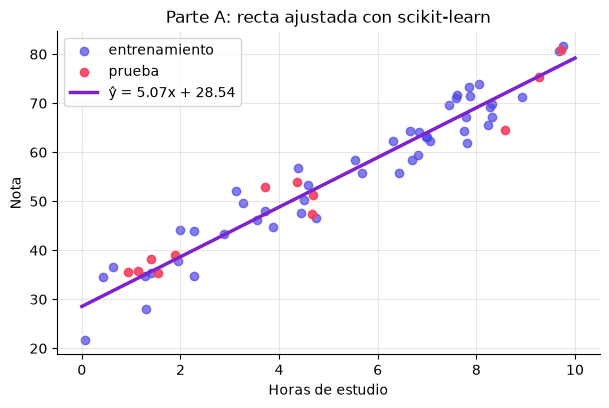

In [8]:
xs = np.linspace(0, 10, 100).reshape(-1, 1)
plt.scatter(X_train, y_train, color=INDIGO, alpha=0.7, label='entrenamiento')
plt.scatter(X_test, y_test, color=CORAL, alpha=0.9, label='prueba')
plt.plot(xs, modelo.predict(xs), color=PURPURA, lw=2.5, label=f'ŷ = {w_sk:.2f}x + {b_sk:.2f}')
plt.xlabel('Horas de estudio'); plt.ylabel('Nota')
plt.title('Parte A: recta ajustada con scikit-learn'); plt.legend()
plt.show()

`LinearRegression` no itera: resuelve el problema de mínimos cuadrados de forma **directa** (algebraicamente). Rápido y exacto, pero oculta el proceso. En la Parte B lo construimos nosotros.

---
# Parte B — Regresión lineal con descenso de gradiente desde cero

## B.1 La función de costo

Para medir qué tan buena es una recta $(w, b)$ usamos el error cuadrático medio (con un factor ½ por conveniencia):

$$J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}\left(\underbrace{w\,x^{(i)} + b}_{\hat{y}^{(i)}} - y^{(i)}\right)^2$$

Entrenar el modelo significa **encontrar el par $(w, b)$ que hace $J$ lo más pequeño posible**.

In [9]:
def costo(w, b, x, y):
    """J(w, b) = (1/2m) Σ (w·x + b − y)²"""
    y_pred = w * x + b
    return np.mean((y_pred - y) ** 2) / 2

x_train, x_test = X_train.ravel(), X_test.ravel()   # para esta parte bastan vectores 1D

print(f'J(0, 0)   = {costo(0, 0, x_train, y_train):8.2f}   <- recta horizontal en 0: muy mala')
print(f'J(5, 30)  = {costo(5, 30, x_train, y_train):8.2f}   <- la relación real: mucho mejor')

J(0, 0)   =  1667.25   <- recta horizontal en 0: muy mala
J(5, 30)  =     7.88   <- la relación real: mucho mejor


## B.2 El gradiente

El **gradiente** son las derivadas parciales de $J$: indica en qué dirección, y con qué intensidad, crece el costo al mover cada parámetro. Aplicando la regla de la cadena:

$$\frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)x^{(i)} \qquad\qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)$$

(El 2 que baja del exponente se cancela con el ½: por eso lo pusimos.)

In [10]:
def gradientes(w, b, x, y):
    """Devuelve (∂J/∂w, ∂J/∂b)."""
    error = (w * x + b) - y          # residuo de cada muestra
    dw = np.mean(error * x)
    db = np.mean(error)
    return dw, db

dw, db = gradientes(0, 0, x_train, y_train)
print(f'En (w, b) = (0, 0):  ∂J/∂w = {dw:.2f},  ∂J/∂b = {db:.2f}')

En (w, b) = (0, 0):  ∂J/∂w = -339.86,  ∂J/∂b = -55.98


Ambos gradientes son **negativos**: aumentar $w$ o $b$ haría bajar el costo. Tiene sentido, porque la recta $\hat{y}=0$ predice muy por debajo de las notas reales.

## B.3 La regla de actualización

El descenso de gradiente da pasos en la dirección **opuesta** al gradiente (cuesta abajo), con un tamaño controlado por la **tasa de aprendizaje** $\alpha$:

$$w \leftarrow w - \alpha\,\frac{\partial J}{\partial w} \qquad\qquad b \leftarrow b - \alpha\,\frac{\partial J}{\partial b}$$

Repetimos esto muchas veces y el par $(w, b)$ se va acercando al mínimo.

<div style="border-left:4px solid #F43F5E; background:#FFF1F2; padding:10px 14px; margin:8px 0; border-radius:4px; color:#111827;"><span style="font-family:monospace; font-size:0.8em; color:#F43F5E; font-weight:bold;">ADVERTENCIA</span> <b>Actualización simultánea</b><br>Los dos gradientes deben calcularse con los valores <b>actuales</b> de <i>w</i> y <i>b</i>, y solo después se actualizan ambos. Nuestra función <code>gradientes</code> calcula <code>dw</code> y <code>db</code> juntos antes de modificar nada, así que lo cumple de forma natural.</div>

## B.4 El algoritmo completo

In [11]:
def descenso_gradiente(x, y, alpha=0.01, iteraciones=10_000):
    w, b = 0.0, 0.0                        # punto de partida
    historial = []                          # guardamos J para analizar la convergencia

    for i in range(iteraciones):
        dw, db = gradientes(w, b, x, y)     # 1) calcular el gradiente
        w = w - alpha * dw                  # 2) dar un paso cuesta abajo
        b = b - alpha * db
        historial.append(costo(w, b, x, y)) # 3) registrar el costo

        if i in (0, 10, 100, 1000, iteraciones - 1):
            print(f'iter {i:>5}:  w = {w:7.4f}   b = {b:8.4f}   J = {historial[-1]:9.4f}')

    return w, b, historial

w_gd, b_gd, historial = descenso_gradiente(x_train, y_train, alpha=0.01, iteraciones=10_000)

iter     0:  w =  3.3986   b =   0.5598   J =  702.4903
iter    10:  w =  8.9765   b =   1.9226   J =   77.3678
iter   100:  w =  8.3954   b =   6.1889   J =   56.6861
iter  1000:  w =  5.6493   b =  24.6320   J =    8.7716
iter  9999:  w =  5.0675   b =  28.5394   J =    7.2610


Observa la evolución: en las primeras iteraciones el costo cae muchísimo y los parámetros cambian rápido; después los cambios son cada vez más finos hasta que $w$ y $b$ se estabilizan.

Hay un detalle curioso: $w$ **se pasa** de su valor final (llega a casi 9) y luego retrocede hacia 5. Ocurre porque el gradiente respecto a $w$ es mucho mayor que respecto a $b$ (los $x$ valen hasta 10), así que al principio casi todo el ajuste lo hace $w$. Como $b$ todavía es pequeño, $w$ "compensa" inclinando de más la recta; a medida que $b$ crece, $w$ vuelve a su lugar.

## B.5 Curva de aprendizaje

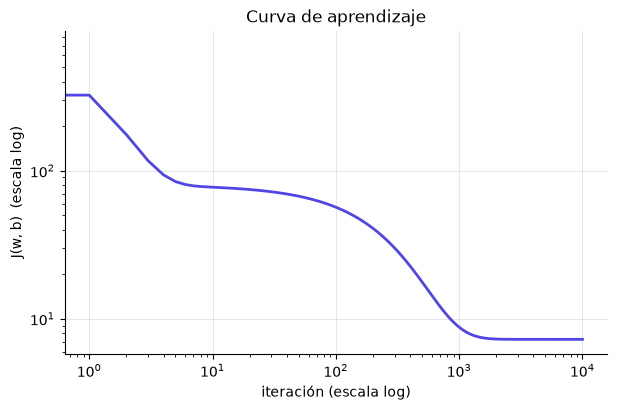

In [12]:
plt.plot(historial, color=INDIGO, lw=2)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('iteración (escala log)'); plt.ylabel('J(w, b)  (escala log)')
plt.title('Curva de aprendizaje')
plt.show()

La **curva de aprendizaje** es la herramienta principal para diagnosticar el entrenamiento. Debe **bajar y luego aplanarse**: la meseta final indica que llegamos al mínimo y que más iteraciones ya no aportan.

Aquí se ven dos fases. Entre las iteraciones 10 y 100 hay una **meseta intermedia**: $w$ ya se ajustó rápido, pero $b$ avanza muy despacio porque su gradiente es pequeño. Recién hacia la iteración 1000 $b$ alcanza su valor y el costo cae a su mínimo. Esa lentitud es el síntoma típico de variables sin escalar.

<div style="border-left:4px solid #4F46E5; background:#EEF2FF; padding:10px 14px; margin:8px 0; border-radius:4px; color:#111827;"><span style="font-family:monospace; font-size:0.8em; color:#4F46E5; font-weight:bold;">IDEA CLAVE</span> <b>Elegir la tasa de aprendizaje α</b><br>Con α muy pequeño la curva baja lentísimo; con α demasiado grande el costo <b>crece</b> en vez de bajar (el algoritmo diverge). Para estos datos el límite está cerca de α ≈ 0.05. Prueba en la celda anterior α = 0.001 y α = 0.06 y observa qué pasa con J. Escalar <i>x</i> (restar la media y dividir por la desviación estándar) permite usar α mucho mayores y converger en muy pocas iteraciones.</div>

## B.6 Evaluar el modelo propio

Usamos los parámetros aprendidos para predecir sobre el conjunto de prueba y calculamos las mismas métricas de la Parte A, esta vez programándolas a mano.

In [13]:
y_pred_gd = w_gd * x_test + b_gd

mae  = np.mean(np.abs(y_test - y_pred_gd))
rmse = np.sqrt(np.mean((y_test - y_pred_gd) ** 2))
r2   = 1 - np.sum((y_test - y_pred_gd) ** 2) / np.sum((y_test - y_test.mean()) ** 2)

print(f'MAE  = {mae:.3f} puntos')
print(f'RMSE = {rmse:.3f} puntos')
print(f'R²   = {r2:.3f}')

MAE  = 2.781 puntos
RMSE = 3.491 puntos
R²   = 0.946


<div style="border-left:4px solid #7E22CE; background:#F5F3FF; padding:10px 14px; margin:8px 0; border-radius:4px; color:#111827;"><span style="font-family:monospace; font-size:0.8em; color:#7E22CE; font-weight:bold;">DEFINICIÓN</span> <b>R² a mano</b><br>R² = 1 − SS<sub>res</sub> / SS<sub>tot</sub>, donde SS<sub>res</sub> es la suma de residuos al cuadrado del modelo y SS<sub>tot</sub> la de un modelo que predice siempre la media. Si nuestro modelo no mejora a la media, R² = 0; si no comete errores, R² = 1.</div>

---
# Comparación de ambos caminos

In [14]:
print(f'{"":22}{"w":>10}{"b":>10}')
print(f'{"Valor real":22}{5:>10.4f}{30:>10.4f}')
print(f'{"scikit-learn":22}{w_sk:>10.4f}{b_sk:>10.4f}')
print(f'{"Descenso de gradiente":22}{w_gd:>10.4f}{b_gd:>10.4f}')
print(f'\nDiferencia |w_sk − w_gd| = {abs(w_sk - w_gd):.2e}')
print(f'Diferencia |b_sk − b_gd| = {abs(b_sk - b_gd):.2e}')

                               w         b
Valor real                5.0000   30.0000
scikit-learn              5.0675   28.5394
Descenso de gradiente     5.0675   28.5394

Diferencia |w_sk − w_gd| = 1.55e-08
Diferencia |b_sk − b_gd| = 1.04e-07


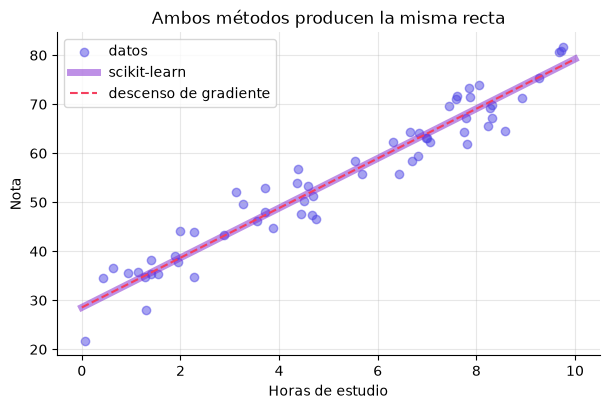

In [15]:
plt.scatter(horas, nota, color=INDIGO, alpha=0.5, label='datos')
plt.plot(xs, modelo.predict(xs), color=PURPURA, lw=5, alpha=0.5, label='scikit-learn')
plt.plot(xs, w_gd * xs + b_gd, color=CORAL, lw=1.5, ls='--', label='descenso de gradiente')
plt.xlabel('Horas de estudio'); plt.ylabel('Nota')
plt.title('Ambos métodos producen la misma recta'); plt.legend()
plt.show()

Las dos rectas se superponen: los parámetros coinciden hasta varios decimales.

| | scikit-learn | Descenso de gradiente |
|---|---|---|
| **Cómo resuelve** | Directamente (álgebra lineal) | Paso a paso, bajando por la función de costo |
| **Resultado** | Exacto | Aproximado; mejora con las iteraciones |
| **Hiperparámetros** | Ninguno | Tasa de aprendizaje α e iteraciones |
| **Líneas de código** | 2 | ~15 |
| **Valor para el curso** | Herramienta de uso diario | Base de la regresión logística y de las redes neuronales |

## Conclusión

Para una regresión lineal real, `LinearRegression` es la opción correcta: exacta y sin ajustes. Pero el descenso de gradiente es el motor que entrena casi todos los modelos que veremos después, porque la mayoría **no tiene** una solución directa. Entenderlo aquí, en el caso más simple, es la preparación para todo lo que sigue.
